## Data & Packages

In [1]:
# Packages 
import polars as pl
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Clustering packages
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Optimisation packages
from scipy.optimize import linear_sum_assignment

In [2]:
# Load data
df = pl.scan_csv("/home/lanl/data/cyber1/auth.txt.gz",has_header=False,separator=",",
                 new_columns= ['time','src_user','dest_user','src_comp','dest_comp',
                               'auth_type','logon_type','auth_orientation','outcome'])

In [3]:
# Keep only human users
df = df.filter(pl.col("src_user").str.starts_with("U"))

In [4]:
# Time conversions
seconds_in_day = 60 * 60 * 24
eight_weeks_seconds = 8 * 7 * seconds_in_day

# Time aggregation
agg_hour_level = 1

# Number of buckets in a week of data
buckets_per_week = (7 * 24) // agg_hour_level

In [5]:
# Keep the first 8 weeks of data
df = df.filter(pl.col("time") <= eight_weeks_seconds)

In [6]:
# Chosen features
feature_cols = [
    'log_n_events',
    'log_n_distinct_src',
    'log_n_distinct_dest',
    'failure_ratio',
    'c_bar',
    's_bar',
    ]

## Functions

In [7]:
# Build the features dataframe
def build_features(df,agg_hour_level):

    agg_seconds = agg_hour_level * 60 * 60 

    return (
        df.with_columns(
            bucket = pl.col('time') // agg_seconds,
            theta = ((pl.col('time') % seconds_in_day)/seconds_in_day) * 2 * np.pi,
            is_failure = (pl.col('outcome') == 'Fail').cast(pl.Int8),
        )
        .group_by(['src_user','bucket'])
        .agg(
            n_events = pl.len(),
            failure_ratio = pl.col('is_failure').mean(),
            n_distinct_src = pl.col('src_comp').n_unique(),
            n_distinct_dest = pl.col('dest_comp').n_unique(),
            c_bar = pl.col('theta').cos().mean(),
            s_bar = pl.col('theta').sin().mean(),
        )
        .with_columns(
            log_n_events = pl.col('n_events').log(),
            log_n_distinct_src = pl.col('n_distinct_src').log(),
            log_n_distinct_dest = pl.col('n_distinct_dest').log(),
        ).collect()
        )

In [8]:
# Process features for clustering
def cluster_preprocess(features_df, X_scaled, week):

    lb = (week - 1) * buckets_per_week
    ub = lb + buckets_per_week - 1

    in_bin = features_df['bucket'].is_between(lb,ub).to_numpy()

    features_week = features_df.filter(in_bin)
    X_scaled_week = X_scaled[in_bin]

    return features_week, X_scaled_week 

## Clustering

In [9]:
# Build the features dataframe
features_df = build_features(df, agg_hour_level)

In [10]:
# Standardise features
X = features_df.select(feature_cols).to_numpy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [22]:
# Cluster for each week 
n_weeks = 8
k = 2
weekly_results = {}

for week in range(1, n_weeks + 1):

    features_week, X_scaled_week = cluster_preprocess(features_df,X_scaled, week)

    km = KMeans(n_clusters=k, random_state=123, n_init=10)
    labels = km.fit_predict(X_scaled_week)

    features_week = (features_week.with_columns(pl.Series('cluster',labels)).select(['src_user','bucket','cluster']))

    weekly_results[week] = features_week

## Label Matching

In [23]:
# Label matching using JACARD index (and hungarian algorithm to solve the optimisation)
JACARD = np.zeros((n_weeks - 1,k,k))
aligned_labels = {}

for week in range(1,n_weeks):
    
    w_curr = weekly_results[week].with_columns(
        relative_bucket=pl.col('bucket') % buckets_per_week
    )

    w_next = weekly_results[week + 1].with_columns(
        relative_bucket=pl.col('bucket') % buckets_per_week
    )

    overlap = w_curr.join(w_next, on=['src_user', 'relative_bucket'], how='inner', suffix='_next')

    labels_curr = overlap['cluster'].to_numpy()
    labels_next = overlap['cluster_next'].to_numpy()

    for i in range(k):
        mask_i = (labels_curr == i)
        
        for j in range(k):
            mask_j = labels_next == j
            intersection = np.sum(mask_i & mask_j)
            union = np.sum(mask_i | mask_j)
            JACARD[week - 1, i,j] = intersection/union 

    _, col_ind = linear_sum_assignment(JACARD[week - 1], maximize=True)

    mapping = {col_ind[c]: c for c in range(k)}
    labels_next = np.array([mapping[label] for label in labels_next])

    aligned_labels[week] = {
        'src_user': overlap['src_user'].to_numpy(),
        'relative_bucket': overlap['relative_bucket'].to_numpy(),
        'labels_curr': labels_curr,
        'labels_next': labels_next,
    }

# Cluster Stability Metrics

In [24]:
d = aligned_labels[1]

stayed = (d['labels_curr'] == d['labels_next'])

keys = pl.DataFrame({
    'src_user':        d['src_user'],
    'relative_bucket': d['relative_bucket'],
})

stayed_set = keys.filter(pl.Series(stayed))
moved_set  = keys.filter(pl.Series(~stayed))

print(f"Stayed: {stayed_set.height}")
print(f"Moved:  {moved_set.height}")

Stayed: 420525
Moved:  195099


In [25]:
d = aligned_labels[1]
stayed = d['labels_curr'] == d['labels_next']

week = 1
lb = (week - 1) * buckets_per_week        # 0 for week 1

stayed_keys = pl.DataFrame({
    'src_user': d['src_user'][stayed],
    'bucket':   d['relative_bucket'][stayed] + lb,   # back to absolute
})

# Attach the row number, then match on the key
features_idx = features_df.with_row_index('row_nr')

matched = stayed_keys.join(features_idx, on=['src_user', 'bucket'], how='inner')

rows = matched['row_nr'].to_numpy()
X_stayed = X_scaled[rows]

print(X_stayed.shape)   # (n_stayed, n_features)

(420525, 6)


In [26]:
d = aligned_labels[1]
stayed = d['labels_curr'] == d['labels_next']

w1, w2 = 1, 2
lb1 = (w1 - 1) * buckets_per_week
lb2 = (w2 - 1) * buckets_per_week

# One row per stayed point, carrying a stable id so both weeks stay aligned
stayed_keys = pl.DataFrame({
    'pair_id':  np.arange(stayed.sum()),
    'src_user': d['src_user'][stayed],
    'rel':      d['relative_bucket'][stayed],
})

features_idx = features_df.with_row_index('row_nr')

def rows_for(bucket_offset):
    q = (
        stayed_keys
        .with_columns(bucket=pl.col('rel') + bucket_offset)
        .join(features_idx, on=['src_user', 'bucket'], how='inner')
        .sort('pair_id')                      # realign to the stable order
    )
    return q

m1 = rows_for(lb1)
m2 = rows_for(lb2)

X_w1 = X_scaled[m1['row_nr'].to_numpy()]
X_w2 = X_scaled[m2['row_nr'].to_numpy()]

print(X_w1.shape, X_w2.shape)

(420525, 6) (420525, 6)


In [27]:
delta = X_w2 - X_w1
delta = delta[:,:-2]

In [28]:
keep = [i for i, c in enumerate(feature_cols) if c not in ('c_bar', 's_bar')]

# difference in the (log or raw) feature space, un-standardised
delta_transformed = delta * scaler.scale_[keep]

In [29]:
delta_transformed

array([[ 0.40546511,  0.        ,  0.        ,  0.        ],
       [-0.8637727 , -0.11778304, -0.2006707 ,  0.        ],
       [ 0.55961579, -0.40546511,  0.40546511,  0.        ],
       ...,
       [ 0.69314718,  0.        ,  0.        ,  0.        ],
       [ 0.00997515, -0.69314718, -0.78845736,  0.        ],
       [ 0.15415068,  0.        ,  0.        ,  0.        ]],
      shape=(420525, 4))

In [30]:
raw_cols = ['n_events', 'n_distinct_src', 'n_distinct_dest', 'failure_ratio']

# m1, m2 already sorted by pair_id and carry the same pair set in the same order
raw_w1 = m1.select(raw_cols).to_numpy()
raw_w2 = m2.select(raw_cols).to_numpy()

raw_delta = raw_w2 - raw_w1   # change in true units, row i = pair_id i

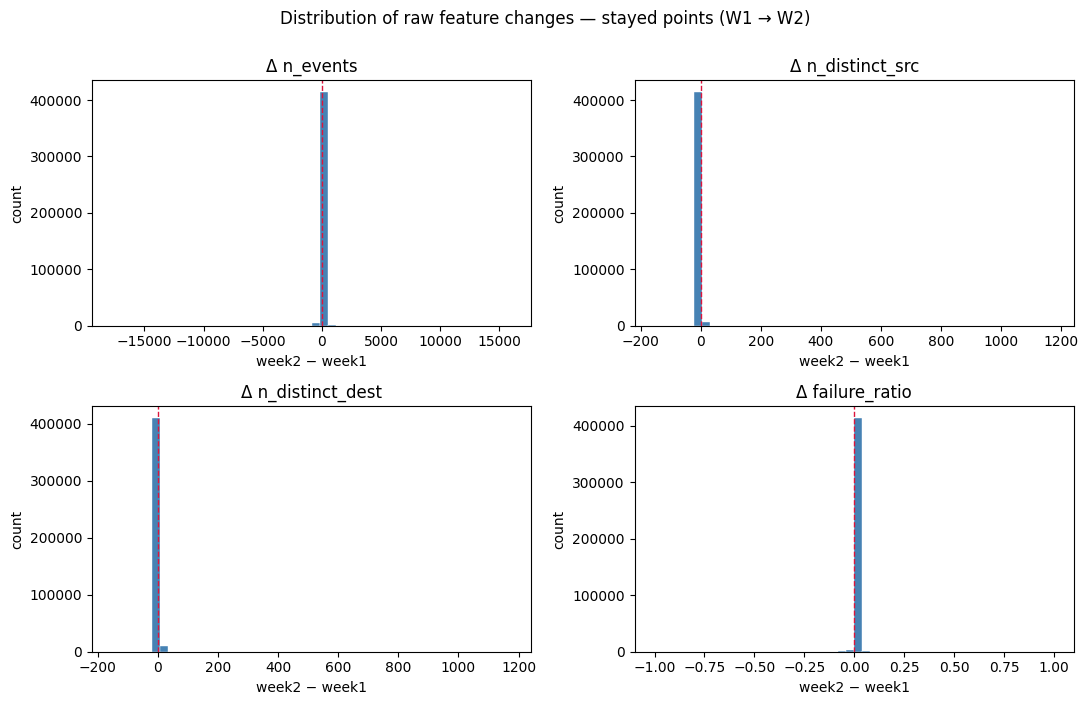

In [31]:
fig, axes = plt.subplots(2, 2, figsize=(11, 7))

for ax, col, vals in zip(axes.flat, raw_cols, raw_delta.T):
    ax.hist(vals, bins=50, color='steelblue', edgecolor='white', linewidth=0.3)
    ax.axvline(0, color='crimson', linestyle='--', linewidth=1)
    ax.set_title(f'Δ {col}')
    ax.set_xlabel('week2 − week1')
    ax.set_ylabel('count')

fig.suptitle('Distribution of raw feature changes — stayed points (W1 → W2)', y=1.0)
plt.tight_layout()
plt.show()

NameError: name 'raw_delta_moved' is not defined

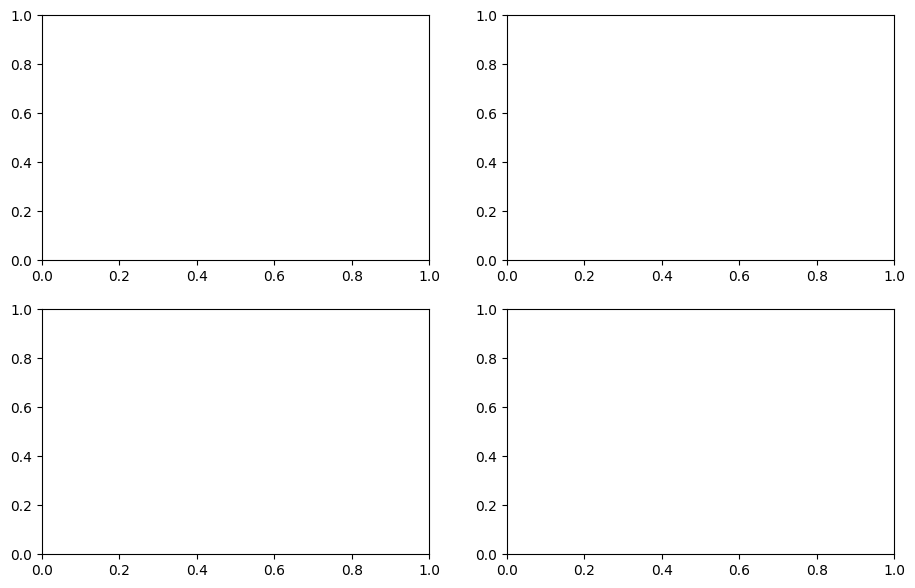

In [21]:
fig, axes = plt.subplots(2, 2, figsize=(11, 7))

for ax, col, vals in zip(axes.flat, raw_cols, raw_delta_moved.T):
    ax.hist(vals, bins=50, color='darkorange', edgecolor='white', linewidth=0.3)
    ax.axvline(0, color='crimson', linestyle='--', linewidth=1)
    ax.set_title(f'Δ {col}')
    ax.set_xlabel('week2 − week1')
    ax.set_ylabel('count')

fig.suptitle('Distribution of raw feature changes — moved points (W1 → W2)', y=1.0)
plt.tight_layout()
plt.show()

Total moved points pooled over 7 pairs: 1481420


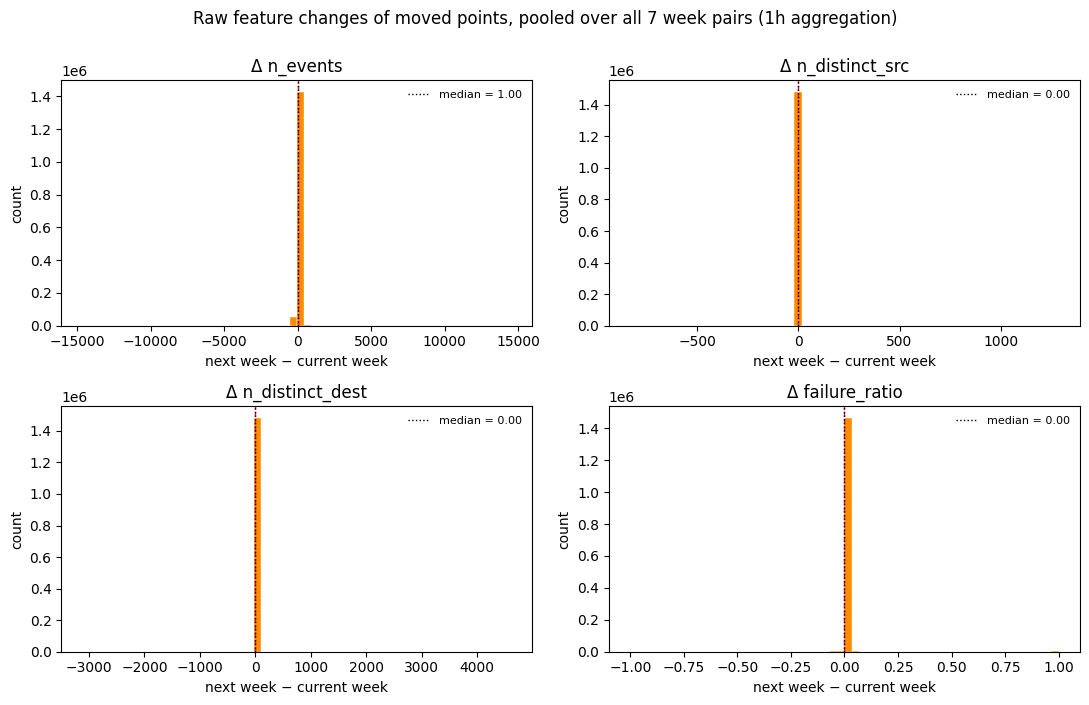

shape: (4, 7)
┌─────────────────┬──────────┬────────┬───────────┬───────────┬───────┬──────┐
│ feature         ┆ mean     ┆ median ┆ std       ┆ mean_abs  ┆ q05   ┆ q95  │
│ ---             ┆ ---      ┆ ---    ┆ ---       ┆ ---       ┆ ---   ┆ ---  │
│ str             ┆ f64      ┆ f64    ┆ f64       ┆ f64       ┆ f64   ┆ f64  │
╞═════════════════╪══════════╪════════╪═══════════╪═══════════╪═══════╪══════╡
│ n_events        ┆ 0.492068 ┆ 1.0    ┆ 79.516803 ┆ 30.245256 ┆ -46.0 ┆ 47.0 │
│ n_distinct_src  ┆ 0.077675 ┆ 0.0    ┆ 3.787639  ┆ 2.94659   ┆ -5.0  ┆ 5.0  │
│ n_distinct_dest ┆ 0.096589 ┆ 0.0    ┆ 6.973418  ┆ 3.731036  ┆ -7.0  ┆ 7.0  │
│ failure_ratio   ┆ 0.000453 ┆ 0.0    ┆ 0.050646  ┆ 0.003389  ┆ 0.0   ┆ 0.0  │
└─────────────────┴──────────┴────────┴───────────┴───────────┴───────┴──────┘


In [33]:
# %% [markdown]
# # Raw feature changes for movers, pooled over all 7 week pairs (1h aggregation)
# Maps moved points back to features_df and works entirely in original units.
# Requires in scope: features_df, aligned_labels, buckets_per_week, n_weeks

# %%
raw_cols = ['n_events', 'n_distinct_src', 'n_distinct_dest', 'failure_ratio']

features_idx = features_df.with_row_index('row_nr')


def mover_raw_deltas(pair):
    """Raw-unit deltas (W_{pair+1} − W_pair) for moved points only."""
    d = aligned_labels[pair]
    moved = d['labels_curr'] != d['labels_next']

    keys = pl.DataFrame({
        'pair_id':  np.arange(moved.sum()),
        'src_user': d['src_user'][moved],
        'rel':      d['relative_bucket'][moved],
    })

    lb_curr = (pair - 1) * buckets_per_week
    lb_next = pair * buckets_per_week

    def match(offset):
        return (
            keys
            .with_columns(bucket=pl.col('rel') + offset)
            .join(features_idx, on=['src_user', 'bucket'], how='inner')
            .sort('pair_id')
        )

    m_curr = match(lb_curr)
    m_next = match(lb_next)

    assert (m_curr['pair_id'] == m_next['pair_id']).all()

    return (m_next.select(raw_cols).to_numpy()
            - m_curr.select(raw_cols).to_numpy())


# %%
# Pool movers over all 7 pairs
raw_delta_moved = np.vstack([mover_raw_deltas(pair) for pair in range(1, n_weeks)])
print(f"Total moved points pooled over {n_weeks - 1} pairs: {raw_delta_moved.shape[0]}")

# %%
fig, axes = plt.subplots(2, 2, figsize=(11, 7))

for ax, col, vals in zip(axes.flat, raw_cols, raw_delta_moved.T):
    ax.hist(vals, bins=60, color='darkorange', edgecolor='white', linewidth=0.3)
    ax.axvline(0, color='crimson', linestyle='--', linewidth=1)
    ax.axvline(np.median(vals), color='black', linestyle=':', linewidth=1,
               label=f'median = {np.median(vals):.2f}')
    ax.set_title(f'Δ {col}')
    ax.set_xlabel('next week − current week')
    ax.set_ylabel('count')
    ax.legend(frameon=False, fontsize=8)

fig.suptitle('Raw feature changes of moved points, pooled over all 7 week pairs '
             '(1h aggregation)', y=1.0)
plt.tight_layout()
plt.show()

# %%
# Summary table of the pooled mover deltas
summary = pl.DataFrame({
    'feature':    raw_cols,
    'mean':       raw_delta_moved.mean(axis=0),
    'median':     np.median(raw_delta_moved, axis=0),
    'std':        raw_delta_moved.std(axis=0),
    'mean_abs':   np.abs(raw_delta_moved).mean(axis=0),
    'q05':        np.quantile(raw_delta_moved, 0.05, axis=0),
    'q95':        np.quantile(raw_delta_moved, 0.95, axis=0),
})
print(summary)

agg =    1 min:   3708053 pooled movers
agg =   10 min:   3164871 pooled movers
agg =   30 min:   2392388 pooled movers
agg =   60 min:   1481370 pooled movers
agg =  120 min:    178463 pooled movers
agg =  180 min:     91168 pooled movers
agg =  240 min:     66455 pooled movers
agg =  360 min:     45939 pooled movers
agg =  480 min:     42632 pooled movers
agg =  720 min:     30818 pooled movers
agg = 1440 min:     20983 pooled movers


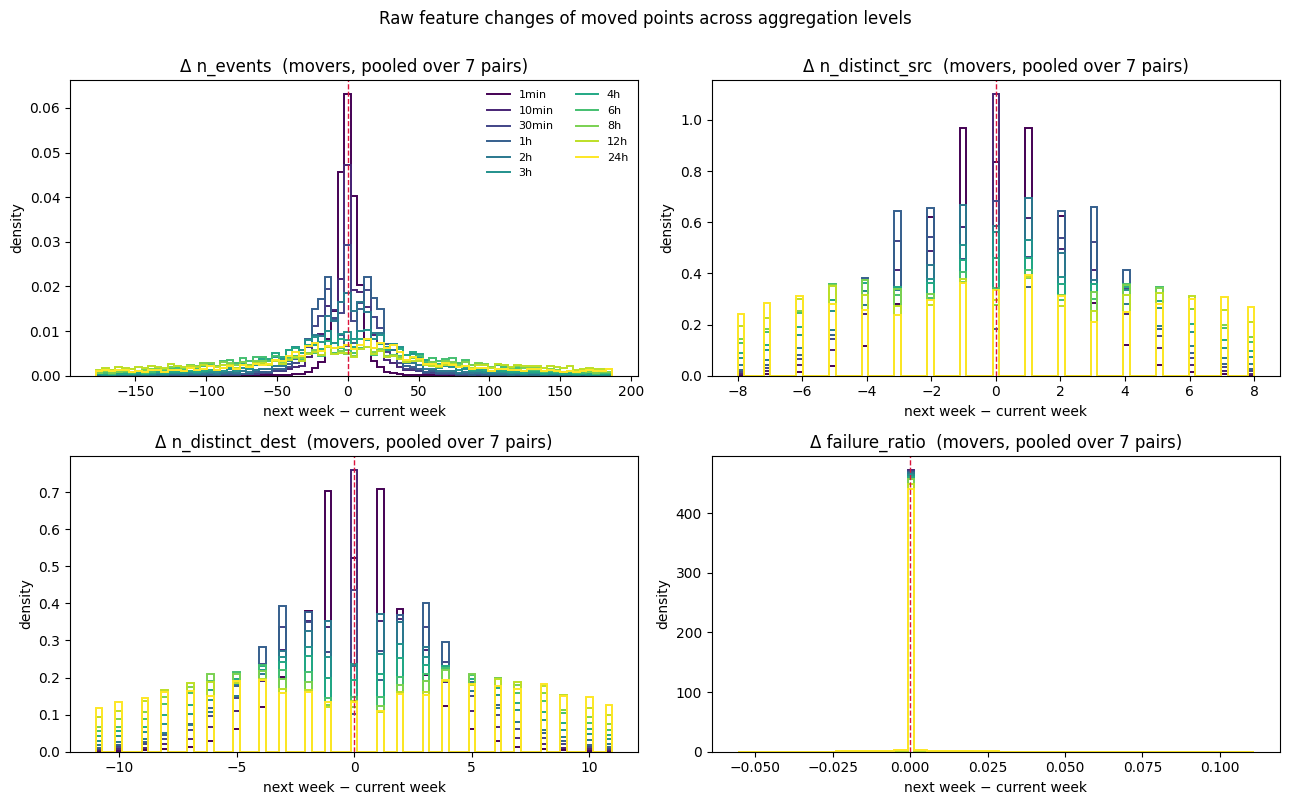

shape: (11, 9)
┌───────────┬───────────┬───────────┬───────────┬───┬───────────┬───────────┬───────────┬──────────┐
│ agg_level ┆ mean_abs_ ┆ mean_abs_ ┆ mean_abs_ ┆ … ┆ median_d_ ┆ median_d_ ┆ median_d_ ┆ median_d │
│ ---       ┆ d_n_event ┆ d_n_disti ┆ d_n_disti ┆   ┆ n_events  ┆ n_distinc ┆ n_distinc ┆ _failure │
│ str       ┆ s         ┆ nct_src   ┆ nct_dest  ┆   ┆ ---       ┆ t_src     ┆ t_dest    ┆ _ratio   │
│           ┆ ---       ┆ ---       ┆ ---       ┆   ┆ f64       ┆ ---       ┆ ---       ┆ ---      │
│           ┆ f64       ┆ f64       ┆ f64       ┆   ┆           ┆ f64       ┆ f64       ┆ f64      │
╞═══════════╪═══════════╪═══════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪══════════╡
│ 1min      ┆ 7.194687  ┆ 1.584838  ┆ 1.854453  ┆ … ┆ 0.0       ┆ 0.0       ┆ 0.0       ┆ 0.0      │
│ 10min     ┆ 14.431153 ┆ 1.956951  ┆ 2.38971   ┆ … ┆ 0.0       ┆ 0.0       ┆ 0.0       ┆ 0.0      │
│ 30min     ┆ 22.197307 ┆ 2.476057  ┆ 3.070252  ┆ … ┆ 0.0       ┆ 0.0       

In [34]:
# %% [markdown]
# # Mover raw feature deltas across aggregation levels
# Reruns the full pipeline (features → global scaling → weekly KMeans →
# Jaccard/Hungarian alignment) for each aggregation level, pools mover
# raw deltas over all 7 week pairs, and overlays the distributions.
#
# Requires in scope: df (the filtered LazyFrame of human users, first 8 weeks),
# feature_cols, seconds_in_day, n_weeks, k

# %%
# Aggregation levels in MINUTES (all divide a week of 10080 minutes exactly)
agg_levels_min = [1, 10, 30, 60, 120, 180, 240, 360, 480, 720, 1440]

raw_cols = ['n_events', 'n_distinct_src', 'n_distinct_dest', 'failure_ratio']
minutes_per_week = 7 * 24 * 60


# %%
def build_features_min(df, agg_minutes):
    """Same as build_features but parameterised in minutes so sub-hour levels work."""
    agg_seconds = agg_minutes * 60

    return (
        df.with_columns(
            bucket = pl.col('time') // agg_seconds,
            theta = ((pl.col('time') % seconds_in_day) / seconds_in_day) * 2 * np.pi,
            is_failure = (pl.col('outcome') == 'Fail').cast(pl.Int8),
        )
        .group_by(['src_user', 'bucket'])
        .agg(
            n_events = pl.len(),
            failure_ratio = pl.col('is_failure').mean(),
            n_distinct_src = pl.col('src_comp').n_unique(),
            n_distinct_dest = pl.col('dest_comp').n_unique(),
            c_bar = pl.col('theta').cos().mean(),
            s_bar = pl.col('theta').sin().mean(),
        )
        .with_columns(
            log_n_events = pl.col('n_events').log(),
            log_n_distinct_src = pl.col('n_distinct_src').log(),
            log_n_distinct_dest = pl.col('n_distinct_dest').log(),
        )
        .collect()
    )


def run_pipeline(agg_minutes):
    """Full pipeline for one aggregation level.
    Returns raw deltas (next − curr) for movers, pooled over all 7 pairs."""

    buckets_per_week = minutes_per_week // agg_minutes

    # --- Features + global scaling -------------------------------------
    features_df = build_features_min(df, agg_minutes)

    X = features_df.select(feature_cols).to_numpy()
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    bucket_np = features_df['bucket'].to_numpy()

    # --- Weekly clustering ----------------------------------------------
    weekly_results = {}
    for week in range(1, n_weeks + 1):
        lb = (week - 1) * buckets_per_week
        ub = lb + buckets_per_week - 1
        in_bin = (bucket_np >= lb) & (bucket_np <= ub)

        km = KMeans(n_clusters=k, random_state=123, n_init=10)
        labels = km.fit_predict(X_scaled[in_bin])

        weekly_results[week] = (
            features_df.filter(pl.Series(in_bin))
            .with_columns(pl.Series('cluster', labels))
            .select(['src_user', 'bucket', 'cluster'])
        )

    # --- Jaccard + Hungarian alignment, then mover deltas per pair ------
    features_idx = features_df.with_row_index('row_nr')
    mover_deltas = []

    for pair in range(1, n_weeks):
        w_curr = weekly_results[pair].with_columns(
            relative_bucket = pl.col('bucket') % buckets_per_week)
        w_next = weekly_results[pair + 1].with_columns(
            relative_bucket = pl.col('bucket') % buckets_per_week)

        overlap = w_curr.join(w_next, on=['src_user', 'relative_bucket'],
                              how='inner', suffix='_next')

        labels_curr = overlap['cluster'].to_numpy()
        labels_next = overlap['cluster_next'].to_numpy()

        # Jaccard overlap matrix
        J = np.zeros((k, k))
        for i in range(k):
            mask_i = labels_curr == i
            for j in range(k):
                mask_j = labels_next == j
                inter = np.sum(mask_i & mask_j)
                union = np.sum(mask_i | mask_j)
                J[i, j] = inter / union if union > 0 else 0.0

        _, col_ind = linear_sum_assignment(J, maximize=True)
        mapping = {col_ind[c]: c for c in range(k)}
        labels_next = np.array([mapping[l] for l in labels_next])

        moved = labels_curr != labels_next
        if moved.sum() == 0:
            continue

        keys = pl.DataFrame({
            'pair_id':  np.arange(moved.sum()),
            'src_user': overlap['src_user'].to_numpy()[moved],
            'rel':      overlap['relative_bucket'].to_numpy()[moved],
        })

        lb_curr = (pair - 1) * buckets_per_week
        lb_next = pair * buckets_per_week

        def match(offset):
            return (
                keys
                .with_columns(bucket=pl.col('rel') + offset)
                .join(features_idx, on=['src_user', 'bucket'], how='inner')
                .sort('pair_id')
            )

        m_curr = match(lb_curr)
        m_next = match(lb_next)
        assert (m_curr['pair_id'] == m_next['pair_id']).all()

        mover_deltas.append(m_next.select(raw_cols).to_numpy()
                            - m_curr.select(raw_cols).to_numpy())

    return np.vstack(mover_deltas)


# %%
# Run everything — the 1-minute level is by far the slowest (most rows for
# KMeans); expect this cell to take a while
mover_deltas_by_level = {}

for agg in agg_levels_min:
    mover_deltas_by_level[agg] = run_pipeline(agg)
    print(f"agg = {agg:>4} min:  {mover_deltas_by_level[agg].shape[0]:>8} "
          f"pooled movers")


# %%
def level_label(agg_minutes):
    return f'{agg_minutes}min' if agg_minutes < 60 else f'{agg_minutes // 60}h'


# %% [markdown]
# ## Overlaid mover delta distributions, one colour per aggregation level
# Density-normalised line histograms (filled histograms with 11 levels are
# unreadable). x-limits clipped to the pooled 0.5–99.5 percentile per feature
# so the heavy tails don't flatten everything.

# %%
cmap = plt.get_cmap('viridis')
colors = {agg: cmap(i / (len(agg_levels_min) - 1))
          for i, agg in enumerate(agg_levels_min)}

fig, axes = plt.subplots(2, 2, figsize=(13, 8))

for ax, col_idx in zip(axes.flat, range(len(raw_cols))):
    # Shared bins per panel from the pooled range across all levels
    pooled = np.concatenate([mover_deltas_by_level[agg][:, col_idx]
                             for agg in agg_levels_min])
    lo, hi = np.quantile(pooled, [0.005, 0.995])
    bins = np.linspace(lo, hi, 80)

    for agg in agg_levels_min:
        vals = mover_deltas_by_level[agg][:, col_idx]
        dens, edges = np.histogram(vals, bins=bins, density=True)
        ax.stairs(dens, edges, color=colors[agg], linewidth=1.4,
                  label=level_label(agg))

    ax.axvline(0, color='crimson', linestyle='--', linewidth=1)
    ax.set_title(f'Δ {raw_cols[col_idx]}  (movers, pooled over 7 pairs)')
    ax.set_xlabel('next week − current week')
    ax.set_ylabel('density')

axes[0, 0].legend(frameon=False, fontsize=8, ncols=2)
fig.suptitle('Raw feature changes of moved points across aggregation levels', y=1.0)
plt.tight_layout()
plt.show()

# %% [markdown]
# ## Summary: mean |Δ| per feature per level

# %%
summary = pl.DataFrame({
    'agg_level': [level_label(a) for a in agg_levels_min],
    **{f'mean_abs_d_{c}': [np.abs(mover_deltas_by_level[a][:, i]).mean()
                           for a in agg_levels_min]
       for i, c in enumerate(raw_cols)},
    **{f'median_d_{c}': [np.median(mover_deltas_by_level[a][:, i])
                         for a in agg_levels_min]
       for i, c in enumerate(raw_cols)},
})
print(summary)